# EKF Comparison — Baseline vs QF-EKF
**Side-by-side: raw EKF (no filter) vs QNN pre-filtered EKF**

Loads two bags simultaneously:
- `BASELINE_BAG` — recorded with `record_baseline_bag.sh`
- `HYBRID_BAG`   — recorded with `record_hybrid_bag.sh`

Both bags must cover same motion profile for fair comparison.

**Key metrics compared:**
1. XY trajectory fidelity
2. Drift rate (m/min)
3. GPS innovation RMSE
4. Velocity tracking accuracy vs cmd_vel
5. IMU noise before/after QNN filter
6. Closure error

In [1]:
# ── SET BAG PATHS ─────────────────────────────────────────────────────────────
BASELINE_BAG = '/home/rosdata/rosbags/moving_bot_baseline_test_20260420_222201'
HYBRID_BAG   = '/home/rosdata/rosbags/moving_bot_live_test_20260420_223434'
PLOT_DIR     = '/home/anish/Multi-sensor-fusion/plots/comparison'
# ─────────────────────────────────────────────────────────────────────────────

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.signal import welch, savgol_filter
from rosbags.highlevel import AnyReader
from rosbags.typesys import Stores, get_typestore

os.makedirs(PLOT_DIR, exist_ok=True)
typestore = get_typestore(Stores.ROS2_HUMBLE)

plt.rcParams.update({
    'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#16213e',
    'axes.edgecolor': '#e0e0e0', 'axes.labelcolor': '#e0e0e0',
    'text.color': '#e0e0e0', 'xtick.color': '#aaaaaa', 'ytick.color': '#aaaaaa',
    'grid.color': '#2a2a4a', 'grid.alpha': 0.5,
    'legend.facecolor': '#16213e', 'legend.edgecolor': '#444444',
    'font.size': 11, 'figure.dpi': 100,
})

# Baseline = red family, QF-EKF = green/blue family
C = {
    'b_wheel':   '#ff6b6b',   # baseline wheel
    'b_ekf_l':   '#ff9f43',   # baseline EKF local
    'b_ekf_g':   '#ffd43b',   # baseline EKF global
    'q_wheel':   '#51cf66',   # QF wheel
    'q_ekf_l':   '#20c997',   # QF EKF local
    'q_ekf_g':   '#339af0',   # QF EKF global
    'imu_raw':   '#ff6b6b',
    'imu_flt':   '#51cf66',
    'gps':       '#a29bfe',
    'cmd_vel':   '#cc5de8',
}

def quat_to_yaw(q):
    siny_cosp = 2.0 * (q.w * q.z + q.x * q.y)
    cosy_cosp = 1.0 - 2.0 * (q.y * q.y + q.z * q.z)
    return np.arctan2(siny_cosp, cosy_cosp)

def npc(df, col):
    return pd.to_numeric(df[col], errors='coerce').to_numpy()

def mask_finite(*arrs):
    m = np.ones(len(arrs[0]), dtype=bool)
    for a in arrs: m &= np.isfinite(a)
    return m

def noise_std(sig):
    wl = min(51, max(5, (len(sig)//5)*2+1))
    if wl % 2 == 0: wl += 1
    if len(sig) < wl: return np.std(sig)
    return np.std(sig - savgol_filter(sig, wl, 3))

print('Bag paths set.')
print(f'  Baseline: {Path(BASELINE_BAG).exists()}')
print(f'  Hybrid  : {Path(HYBRID_BAG).exists()}')

/home/anish/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Bag paths set.
  Baseline: True
  Hybrid  : True


## 1. Extract Both Bags

In [2]:
def extract_bag(bag_path, is_hybrid=False):
    """Extract odometry, IMU, GPS from a bag. Returns dict of DataFrames."""
    keys = ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global',
            'imu', 'gps', 'cmd_vel']
    if is_hybrid:
        keys += ['wheel_flt', 'visual_flt', 'lidar_flt', 'imu_flt']
    raw = {k: [] for k in keys}

    TOPIC_MAP = {
        '/diff_drive_controller/odom':          'wheel',
        '/odometry/visual':                     'visual',
        '/odometry/lidar':                      'lidar',
        '/odometry/local':                      'ekf_local',
        '/odometry/global':                     'ekf_global',
        '/imu/data':                            'imu',
        '/gps/fix':                             'gps',
        '/cmd_vel':                             'cmd_vel',
    }
    if is_hybrid:
        TOPIC_MAP.update({
            '/diff_drive_controller/odom/filtered': 'wheel_flt',
            '/odometry/visual/filtered':            'visual_flt',
            '/odometry/lidar/filtered':             'lidar_flt',
            '/imu/data/filtered':                   'imu_flt',
        })

    with AnyReader([Path(bag_path)], default_typestore=typestore) as reader:
        for connection, timestamp, rawdata in reader.messages():
            key = TOPIC_MAP.get(connection.topic)
            if key is None or key not in raw: continue
            msg = reader.deserialize(rawdata, connection.msgtype)
            t = timestamp * 1e-9

            if key in ('wheel','visual','lidar','ekf_local','ekf_global',
                       'wheel_flt','visual_flt','lidar_flt'):
                raw[key].append({'t': t,
                    'x': msg.pose.pose.position.x,
                    'y': msg.pose.pose.position.y,
                    'yaw': quat_to_yaw(msg.pose.pose.orientation),
                    'vx': msg.twist.twist.linear.x,
                    'wz': msg.twist.twist.angular.z,
                    'cov_xx': msg.pose.covariance[0],
                    'cov_yy': msg.pose.covariance[7],
                })
            elif key in ('imu', 'imu_flt'):
                raw[key].append({'t': t,
                    'ax': msg.linear_acceleration.x,
                    'ay': msg.linear_acceleration.y,
                    'az': msg.linear_acceleration.z,
                    'gx': msg.angular_velocity.x,
                    'gy': msg.angular_velocity.y,
                    'gz': msg.angular_velocity.z,
                    'yaw': quat_to_yaw(msg.orientation),
                })
            elif key == 'gps':
                raw[key].append({'t': t, 'lat': msg.latitude, 'lon': msg.longitude})
            elif key == 'cmd_vel':
                raw[key].append({'t': t, 'vx': msg.linear.x, 'wz': msg.angular.z})

    dfs = {}
    t0 = min(raw[k][0]['t'] for k in raw if raw[k])
    for k, rows in raw.items():
        if rows:
            df = pd.DataFrame(rows)
            df['t'] -= t0
            dfs[k] = df
    return dfs


print('Extracting baseline bag...')
B = extract_bag(BASELINE_BAG, is_hybrid=False)
print(f'  Baseline: {list(B.keys())}')

print('\nExtracting hybrid bag...')
Q = extract_bag(HYBRID_BAG, is_hybrid=True)
print(f'  Hybrid:   {list(Q.keys())}')

# Summaries
for label, dfs in [('BASELINE', B), ('QF-EKF', Q)]:
    print(f'\n{label}:')
    for k, df in dfs.items():
        dur = df['t'].iloc[-1] - df['t'].iloc[0] if len(df) > 1 else 0
        hz  = len(df) / dur if dur > 0 else 0
        print(f'  {k:>15}  {len(df):6d} msgs  {dur:6.1f}s  {hz:6.1f} Hz')

Extracting baseline bag...
  Baseline: ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global', 'imu', 'gps', 'cmd_vel']

Extracting hybrid bag...
  Hybrid:   ['wheel', 'visual', 'lidar', 'ekf_local', 'ekf_global', 'imu', 'gps', 'cmd_vel', 'wheel_flt', 'visual_flt', 'lidar_flt', 'imu_flt']

BASELINE:
            wheel    2656 msgs   120.0s    22.1 Hz
           visual    1020 msgs   126.8s     8.0 Hz
            lidar     284 msgs   126.4s     2.2 Hz
        ekf_local    2844 msgs   127.0s    22.4 Hz
       ekf_global    2844 msgs   127.0s    22.4 Hz
              imu   11374 msgs   127.0s    89.6 Hz
              gps     569 msgs   126.8s     4.5 Hz
          cmd_vel    2395 msgs   124.2s    19.3 Hz

QF-EKF:
            wheel    2634 msgs   136.9s    19.2 Hz
           visual      84 msgs   131.5s     0.6 Hz
            lidar     263 msgs   136.2s     1.9 Hz
        ekf_local    2634 msgs   136.9s    19.2 Hz
       ekf_global    2623 msgs   137.0s    19.1 Hz
              imu   10535 m

## 2. Trajectory Comparison — Baseline EKF vs QF-EKF

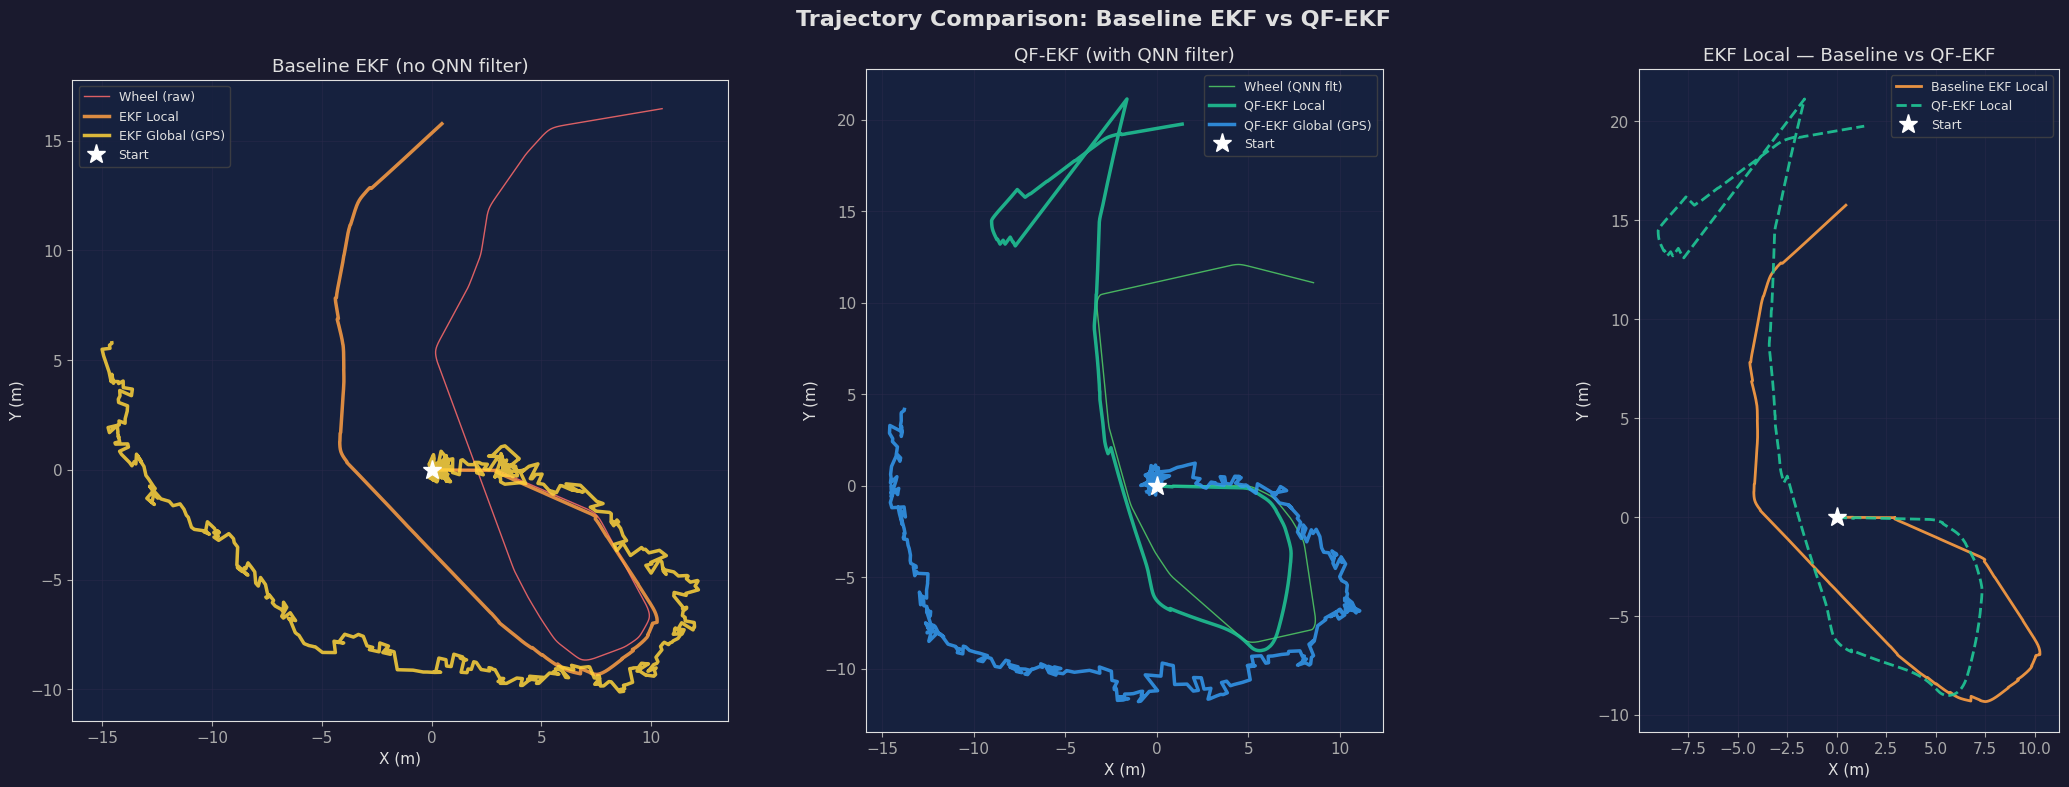


Closure errors:
              Source    Closure error
──────────────────────────────────────
  Baseline EKF Local          15.7815 m
 Baseline EKF Global          15.6874 m
        QF-EKF Local          19.8142 m
       QF-EKF Global          13.9886 m


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Trajectory Comparison: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

# Left: Baseline
ax = axes[0]; ax.set_title('Baseline EKF (no QNN filter)')
for k, label, color, lw in [
    ('wheel',      'Wheel (raw)',        C['b_wheel'], 1.0),
    ('ekf_local',  'EKF Local',          C['b_ekf_l'], 2.5),
    ('ekf_global', 'EKF Global (GPS)',   C['b_ekf_g'], 2.5),
]:
    if k not in B: continue
    x = npc(B[k],'x'); y = npc(B[k],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=color, lw=lw, label=label, alpha=0.85)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Middle: QF-EKF
ax = axes[1]; ax.set_title('QF-EKF (with QNN filter)')
for k, label, color, lw in [
    ('wheel_flt',  'Wheel (QNN flt)',    C['q_wheel'], 1.0),
    ('ekf_local',  'QF-EKF Local',       C['q_ekf_l'], 2.5),
    ('ekf_global', 'QF-EKF Global (GPS)',C['q_ekf_g'], 2.5),
]:
    if k not in Q: continue
    x = npc(Q[k],'x'); y = npc(Q[k],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=color, lw=lw, label=label, alpha=0.85)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

# Right: EKF Local overlay (direct comparison)
ax = axes[2]; ax.set_title('EKF Local — Baseline vs QF-EKF')
if 'ekf_local' in B:
    x = npc(B['ekf_local'],'x'); y = npc(B['ekf_local'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=C['b_ekf_l'], lw=2, label='Baseline EKF Local', alpha=0.9)
if 'ekf_local' in Q:
    x = npc(Q['ekf_local'],'x'); y = npc(Q['ekf_local'],'y'); m = mask_finite(x,y)
    ax.plot(x[m], y[m], color=C['q_ekf_l'], lw=2, ls='--', label='QF-EKF Local', alpha=0.9)
ax.plot(0,0,'w*',ms=14,zorder=10,label='Start')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_aspect('equal'); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/01_trajectory_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClosure errors:')
print(f'{"Source":>20}  {"Closure error":>15}')
print('─' * 38)
for label, dfs, k in [('Baseline EKF Local',B,'ekf_local'),
                        ('Baseline EKF Global',B,'ekf_global'),
                        ('QF-EKF Local',Q,'ekf_local'),
                        ('QF-EKF Global',Q,'ekf_global')]:
    if k not in dfs: continue
    x = npc(dfs[k],'x'); y = npc(dfs[k],'y'); m = mask_finite(x,y)
    if m.sum() < 2: continue
    err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
    print(f'{label:>20}  {err:15.4f} m')

## 3. Drift Comparison — Baseline EKF vs QF-EKF

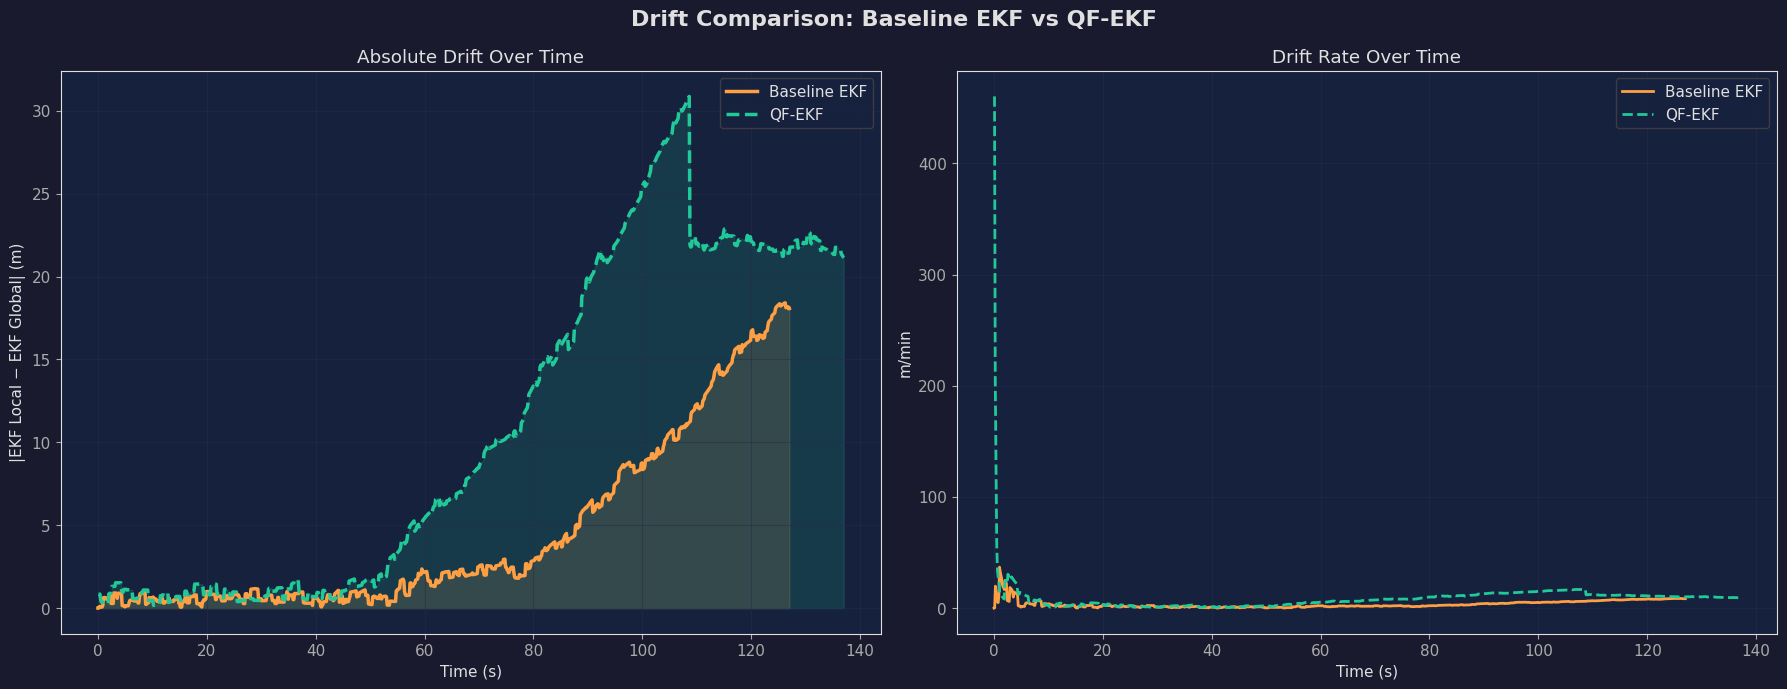


Drift Summary:
                  Final drift   Max drift   Rate (m/min)
────────────────────────────────────────────────────────
   Baseline EKF       18.0701     18.4139         8.5380
         QF-EKF       21.1303     30.8620         9.2633

QF-EKF drift improvement: -18.9%


In [4]:
def compute_drift(dfs):
    if 'ekf_local' not in dfs or 'ekf_global' not in dfs:
        return None, None
    tl = npc(dfs['ekf_local'],'t');  xl = npc(dfs['ekf_local'],'x');  yl = npc(dfs['ekf_local'],'y')
    tg = npc(dfs['ekf_global'],'t'); xg = npc(dfs['ekf_global'],'x'); yg = npc(dfs['ekf_global'],'y')
    ml = mask_finite(tl,xl,yl); mg = mask_finite(tg,xg,yg)
    if ml.sum() < 2 or mg.sum() < 2: return None, None
    t_c = np.linspace(max(tl[ml][0],tg[mg][0]), min(tl[ml][-1],tg[mg][-1]), 1000)
    lx = np.interp(t_c, tl[ml], xl[ml]-xl[ml][0])
    ly = np.interp(t_c, tl[ml], yl[ml]-yl[ml][0])
    gx = np.interp(t_c, tg[mg], xg[mg]-xg[mg][0])
    gy = np.interp(t_c, tg[mg], yg[mg]-yg[mg][0])
    drift = np.sqrt((lx-gx)**2 + (ly-gy)**2)
    return t_c, drift

t_b, drift_b = compute_drift(B)
t_q, drift_q = compute_drift(Q)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Drift Comparison: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

ax = axes[0]
if t_b is not None:
    ax.plot(t_b, drift_b, color=C['b_ekf_l'], lw=2.5, label='Baseline EKF')
    ax.fill_between(t_b, 0, drift_b, color=C['b_ekf_l'], alpha=0.15)
if t_q is not None:
    ax.plot(t_q, drift_q, color=C['q_ekf_l'], lw=2.5, ls='--', label='QF-EKF')
    ax.fill_between(t_q, 0, drift_q, color=C['q_ekf_l'], alpha=0.15)
ax.set_xlabel('Time (s)'); ax.set_ylabel('|EKF Local − EKF Global| (m)')
ax.set_title('Absolute Drift Over Time'); ax.legend(); ax.grid(True)

ax2 = axes[1]
if t_b is not None:
    ax2.plot(t_b, drift_b/(t_b+1e-6)*60, color=C['b_ekf_l'], lw=2, label='Baseline EKF')
if t_q is not None:
    ax2.plot(t_q, drift_q/(t_q+1e-6)*60, color=C['q_ekf_l'], lw=2, ls='--', label='QF-EKF')
ax2.set_xlabel('Time (s)'); ax2.set_ylabel('m/min')
ax2.set_title('Drift Rate Over Time'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/02_drift_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nDrift Summary:')
print(f'{"":>15}  {"Final drift":>12}  {"Max drift":>10}  {"Rate (m/min)":>13}')
print('─' * 56)
for label, t_c, drift in [('Baseline EKF', t_b, drift_b), ('QF-EKF', t_q, drift_q)]:
    if t_c is None: continue
    dur = t_c[-1] - t_c[0]
    print(f'{label:>15}  {drift[-1]:12.4f}  {drift.max():10.4f}  {drift[-1]/dur*60:13.4f}')

if t_b is not None and t_q is not None:
    t_common = np.linspace(max(t_b[0],t_q[0]), min(t_b[-1],t_q[-1]), 500)
    db = np.interp(t_common, t_b, drift_b)
    dq = np.interp(t_common, t_q, drift_q)
    improvement = (1 - dq[-1]/db[-1]) * 100 if db[-1] > 0 else 0
    print(f'\nQF-EKF drift improvement: {improvement:.1f}%')

## 4. Velocity Tracking — Baseline vs QF-EKF

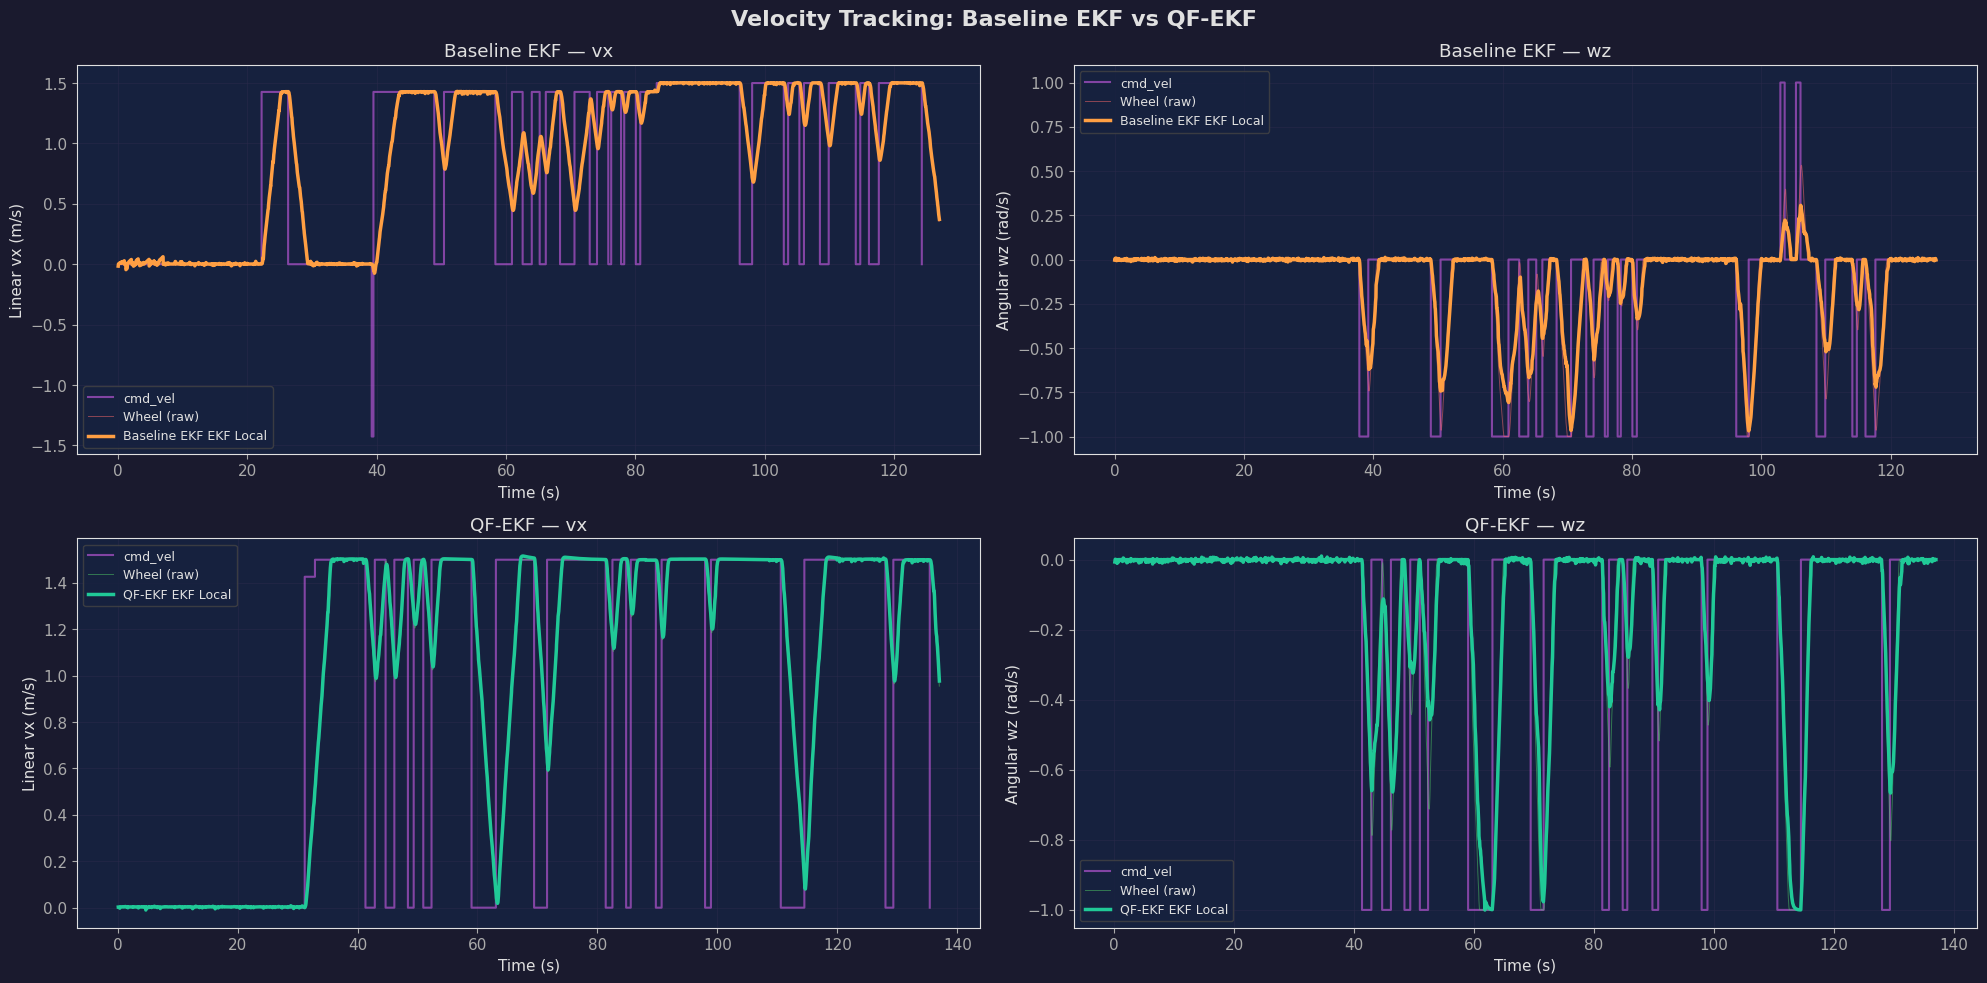


Velocity RMSE vs cmd_vel:
                    vx RMSE     wz RMSE
────────────────────────────────────────
   Baseline EKF      0.5210      0.3242
         QF-EKF      0.5511      0.2985


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.suptitle('Velocity Tracking: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

for col_i, (col, ylabel) in enumerate([('vx','Linear vx (m/s)'), ('wz','Angular wz (rad/s)')]):
    for row, (label, dfs, clr_ekf, clr_raw) in enumerate([
        ('Baseline EKF', B, C['b_ekf_l'], C['b_wheel']),
        ('QF-EKF',       Q, C['q_ekf_l'], C['q_wheel']),
    ]):
        ax = axes[row, col_i]
        cmd_k = 'cmd_vel'
        if cmd_k in dfs:
            t = npc(dfs[cmd_k],'t'); v = npc(dfs[cmd_k], col)
            m = mask_finite(t, v)
            ax.step(t[m], v[m], color=C['cmd_vel'], lw=1.5, where='post',
                    alpha=0.6, label='cmd_vel')
        if 'wheel' in dfs:
            t = npc(dfs['wheel'],'t'); v = npc(dfs['wheel'], col)
            m = mask_finite(t, v)
            ax.plot(t[m], v[m], color=clr_raw, lw=0.7, alpha=0.5, label='Wheel (raw)')
        if 'ekf_local' in dfs:
            t = npc(dfs['ekf_local'],'t'); v = npc(dfs['ekf_local'], col)
            m = mask_finite(t, v)
            ax.plot(t[m], v[m], color=clr_ekf, lw=2.5, label=f'{label} EKF Local')
        ax.set_ylabel(ylabel); ax.set_xlabel('Time (s)')
        ax.set_title(f'{label} — {col}'); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_velocity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVelocity RMSE vs cmd_vel:')
print(f'{"":>15}  {"vx RMSE":>10}  {"wz RMSE":>10}')
print('─' * 40)
for label, dfs in [('Baseline EKF', B), ('QF-EKF', Q)]:
    if 'cmd_vel' not in dfs or 'ekf_local' not in dfs: continue
    tc = npc(dfs['cmd_vel'],'t')
    rmse_vals = []
    for col in ['vx', 'wz']:
        vc = npc(dfs['cmd_vel'], col); mc = mask_finite(tc, vc)
        te = npc(dfs['ekf_local'],'t'); ve = npc(dfs['ekf_local'], col)
        me = mask_finite(te, ve)
        ve_i = np.interp(tc[mc], te[me], ve[me])
        rmse_vals.append(np.sqrt(np.mean((vc[mc]-ve_i)**2)))
    print(f'{label:>15}  {rmse_vals[0]:10.4f}  {rmse_vals[1]:10.4f}')

## 5. IMU Noise — Raw vs QNN Filtered

   Channel      Raw σ      QNN σ   Noise reduc%   SNR gain dB
────────────────────────────────────────────────────────────
    Gyro Z    0.01076    0.00965          10.3%          0.95 dB
    Gyro X    0.00883    0.00000         100.0%         79.86 dB
    Gyro Y    0.00876    0.00000         100.0%         69.46 dB
   Accel X    0.25076    0.07049          71.9%         11.02 dB
   Accel Y    0.22970    0.08303          63.9%          8.84 dB
   Accel Z    0.05459    0.00169          96.9%         30.18 dB


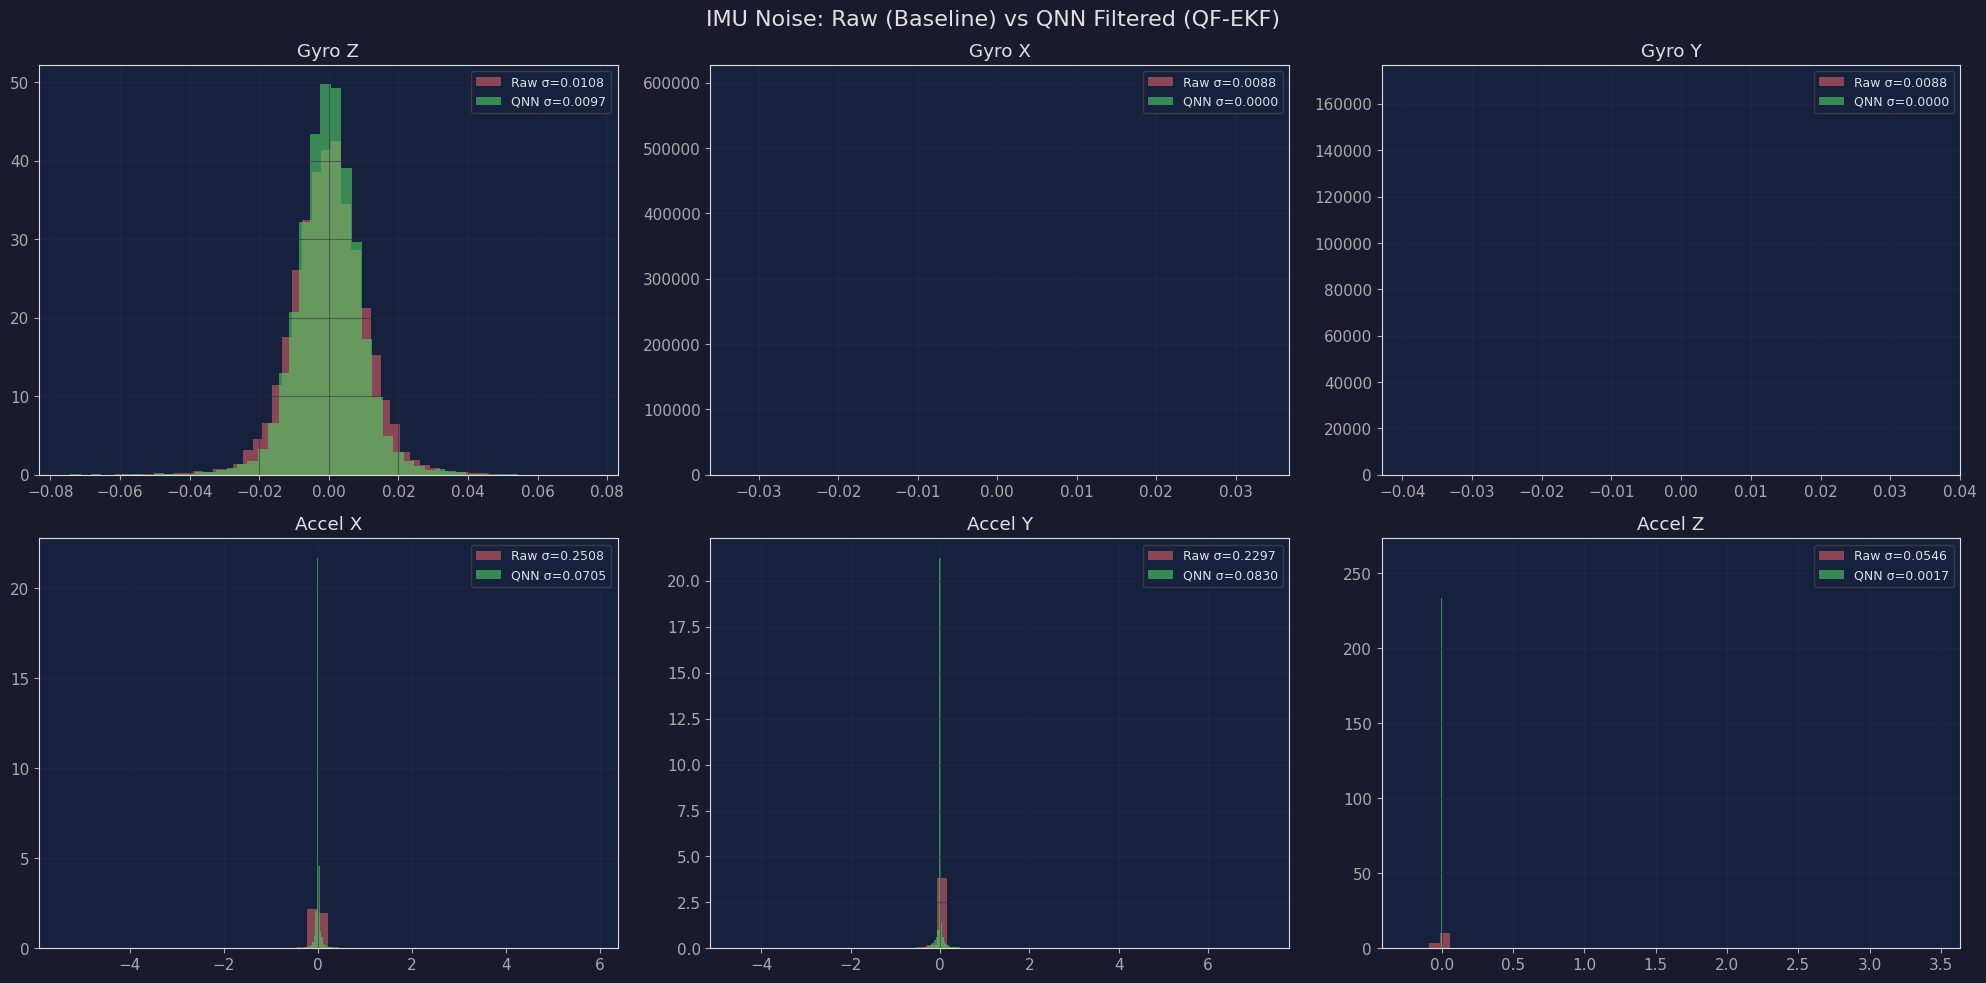

In [6]:
channels = [
    ('gz','Gyro Z'), ('gx','Gyro X'), ('gy','Gyro Y'),
    ('ax','Accel X'), ('ay','Accel Y'), ('az','Accel Z'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('IMU Noise: Raw (Baseline) vs QNN Filtered (QF-EKF)', fontsize=16)

print(f'{"Channel":>10}  {"Raw σ":>9}  {"QNN σ":>9}  {"Noise reduc%":>13}  {"SNR gain dB":>12}')
print('─' * 60)

for ax, (col, label) in zip(axes.flat, channels):
    # Raw from baseline bag
    dr, dq = None, None
    if 'imu' in B:
        d = npc(B['imu'], col); d = d[np.isfinite(d)]
        dr = d
        std_r = noise_std(dr)
        wl = min(51, max(5, (len(dr)//5)*2+1))
        if wl%2==0: wl+=1
        nr = dr - savgol_filter(dr, wl, 3)
        ax.hist(nr, bins=50, density=True, color=C['imu_raw'],
                alpha=0.5, label=f'Raw σ={std_r:.4f}')

    # Filtered from hybrid bag
    if 'imu_flt' in Q:
        d = npc(Q['imu_flt'], col); d = d[np.isfinite(d)]
        dq = d
        std_f = noise_std(dq)
        wl = min(51, max(5, (len(dq)//5)*2+1))
        if wl%2==0: wl+=1
        nf = dq - savgol_filter(dq, wl, 3)
        ax.hist(nf, bins=50, density=True, color=C['imu_flt'],
                alpha=0.6, label=f'QNN σ={std_f:.4f}')

        if dr is not None:
            red = (1 - std_f/std_r)*100 if std_r > 0 else 0
            snr = 20*np.log10(std_r/std_f) if std_f > 0 else 0
            print(f'{label:>10}  {std_r:9.5f}  {std_f:9.5f}  {red:12.1f}%  {snr:12.2f} dB')

    ax.set_title(label); ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/04_imu_noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. GPS Innovation Comparison

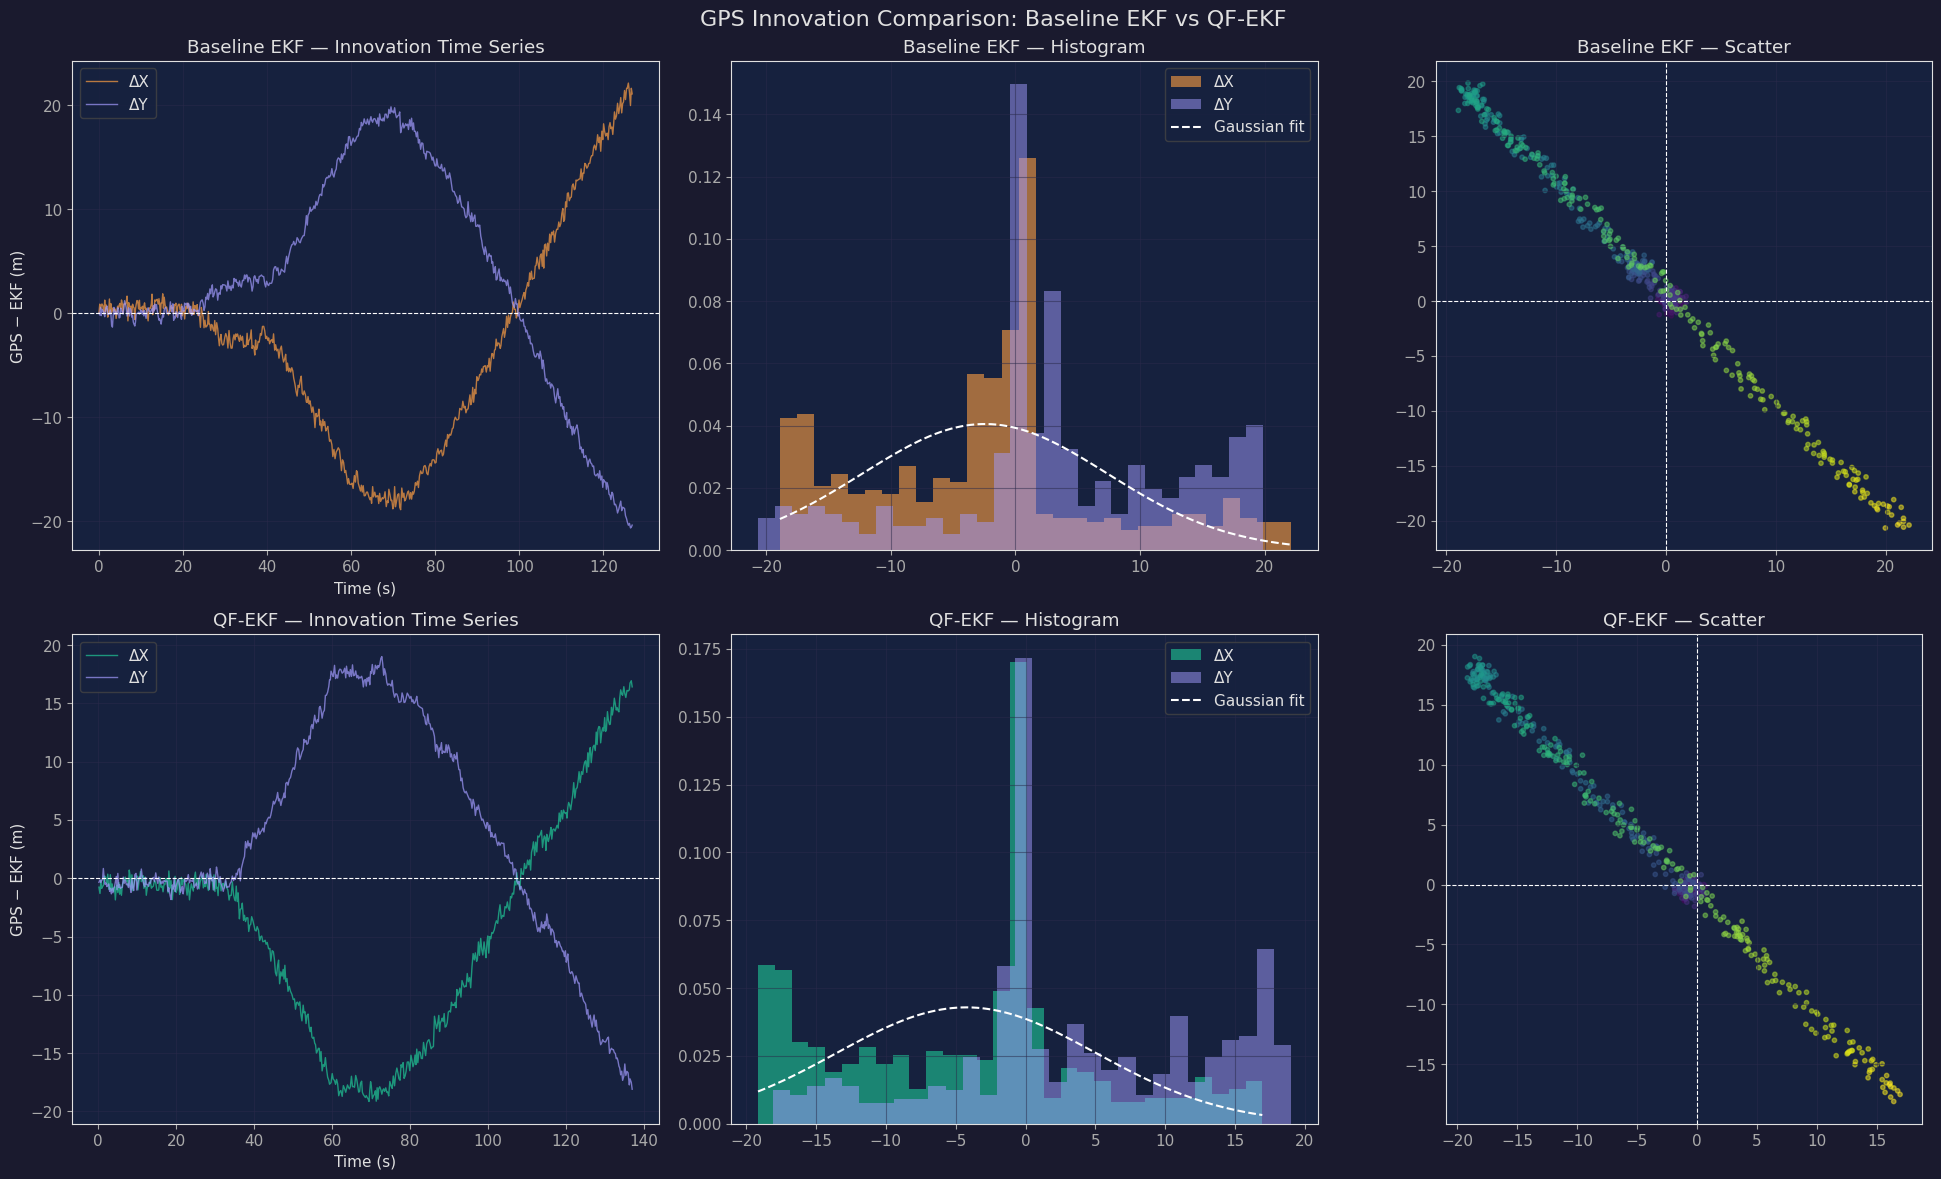


GPS Innovation Statistics:
                   ΔX mean    ΔX std    ΔY mean    ΔY std    2D RMSE
─────────────────────────────────────────────────────────────────
   Baseline EKF    -2.4569    9.8407     3.1229    9.8981    14.5121
         QF-EKF    -4.2421    9.3040     3.3931    9.3793    14.2844

GPS RMSE improvement: 1.6%


In [7]:
def compute_innovation(dfs):
    if 'gps' not in dfs or 'ekf_global' not in dfs:
        return None, None, None
    gps = dfs['gps']; ekf = dfs['ekf_global']
    lat = npc(gps,'lat'); lon = npc(gps,'lon')
    lat_m = (lat - lat[0]) * 111320
    lon_m = (lon - lon[0]) * 111320 * np.cos(np.radians(lat[0]))
    tg = npc(gps,'t'); te = npc(ekf,'t')
    xe = npc(ekf,'x'); ye = npc(ekf,'y')
    me = mask_finite(te, xe, ye)
    lat_m += xe[me][0] - lat_m[0]; lon_m += ye[me][0] - lon_m[0]
    mg = mask_finite(tg, lat_m, lon_m)
    ix = lat_m[mg] - np.interp(tg[mg], te[me], xe[me])
    iy = lon_m[mg] - np.interp(tg[mg], te[me], ye[me])
    return tg[mg], ix, iy

t_b_i, ix_b, iy_b = compute_innovation(B)
t_q_i, ix_q, iy_q = compute_innovation(Q)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('GPS Innovation Comparison: Baseline EKF vs QF-EKF', fontsize=16)

for row, (t_i, ix, iy, label, clr) in enumerate([
    (t_b_i, ix_b, iy_b, 'Baseline EKF', C['b_ekf_l']),
    (t_q_i, ix_q, iy_q, 'QF-EKF',       C['q_ekf_l']),
]):
    if t_i is None: continue

    axes[row,0].plot(t_i, ix, color=clr, lw=1, alpha=0.7, label='ΔX')
    axes[row,0].plot(t_i, iy, color=C['gps'], lw=1, alpha=0.7, label='ΔY')
    axes[row,0].axhline(0, color='white', ls='--', lw=0.8)
    axes[row,0].set_title(f'{label} — Innovation Time Series')
    axes[row,0].set_xlabel('Time (s)'); axes[row,0].set_ylabel('GPS − EKF (m)')
    axes[row,0].legend(); axes[row,0].grid(True)

    axes[row,1].hist(ix, bins=30, color=clr, alpha=0.6, density=True, label='ΔX')
    axes[row,1].hist(iy, bins=30, color=C['gps'], alpha=0.5, density=True, label='ΔY')
    xr = np.linspace(ix.min(), ix.max(), 100)
    axes[row,1].plot(xr, stats.norm.pdf(xr, ix.mean(), ix.std()), 'w--', lw=1.5, label='Gaussian fit')
    axes[row,1].set_title(f'{label} — Histogram'); axes[row,1].legend(); axes[row,1].grid(True)

    axes[row,2].scatter(ix, iy, c=t_i, cmap='viridis', s=10, alpha=0.5)
    axes[row,2].axhline(0, color='white', ls='--', lw=0.8)
    axes[row,2].axvline(0, color='white', ls='--', lw=0.8)
    axes[row,2].set_title(f'{label} — Scatter')
    axes[row,2].set_aspect('equal'); axes[row,2].grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/05_innovation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGPS Innovation Statistics:')
print(f'{"":>15}  {"ΔX mean":>9}  {"ΔX std":>8}  {"ΔY mean":>9}  {"ΔY std":>8}  {"2D RMSE":>9}')
print('─' * 65)
for label, ix, iy in [('Baseline EKF', ix_b, iy_b), ('QF-EKF', ix_q, iy_q)]:
    if ix is None: continue
    rmse = np.sqrt(np.mean(ix**2 + iy**2))
    print(f'{label:>15}  {ix.mean():9.4f}  {ix.std():8.4f}  {iy.mean():9.4f}  {iy.std():8.4f}  {rmse:9.4f}')

if ix_b is not None and ix_q is not None:
    rmse_b = np.sqrt(np.mean(ix_b**2 + iy_b**2))
    rmse_q = np.sqrt(np.mean(ix_q**2 + iy_q**2))
    print(f'\nGPS RMSE improvement: {(1 - rmse_q/rmse_b)*100:.1f}%')

## 7. Yaw Accuracy Comparison

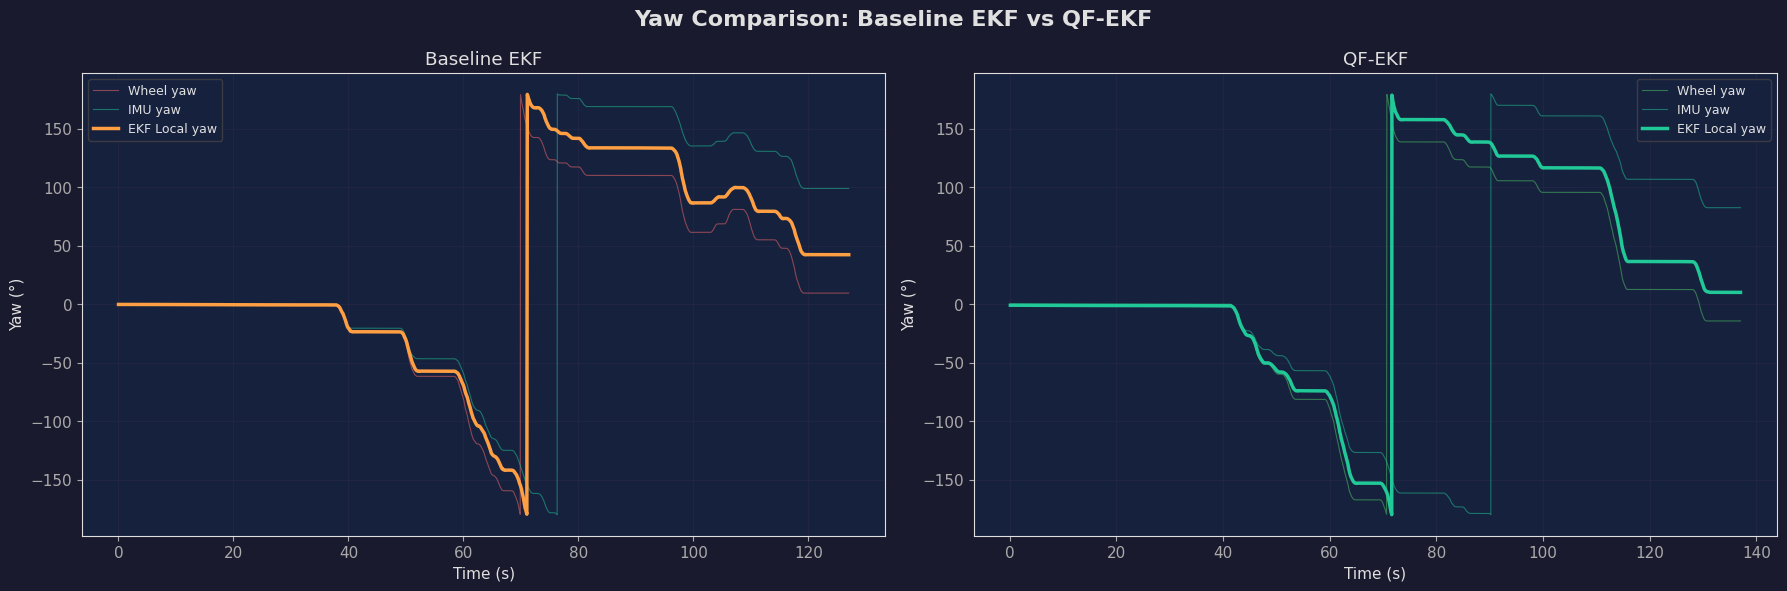

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Yaw Comparison: Baseline EKF vs QF-EKF', fontsize=16, fontweight='bold')

for ax, (label, dfs, c_ekf, c_wheel) in zip(axes, [
    ('Baseline EKF', B, C['b_ekf_l'], C['b_wheel']),
    ('QF-EKF',       Q, C['q_ekf_l'], C['q_wheel']),
]):
    if 'wheel' in dfs:
        t = npc(dfs['wheel'],'t'); y = np.degrees(npc(dfs['wheel'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color=c_wheel, lw=0.8, alpha=0.5, label='Wheel yaw')
    if 'imu' in dfs:
        t = npc(dfs['imu'],'t'); y = np.degrees(npc(dfs['imu'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color='#20c997', lw=0.8, alpha=0.5, label='IMU yaw')
    if 'ekf_local' in dfs:
        t = npc(dfs['ekf_local'],'t'); y = np.degrees(npc(dfs['ekf_local'],'yaw'))
        m = mask_finite(t,y)
        ax.plot(t[m], y[m], color=c_ekf, lw=2.5, label='EKF Local yaw')
    ax.set_title(label); ax.set_xlabel('Time (s)'); ax.set_ylabel('Yaw (°)')
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/06_yaw_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. EKF Covariance Comparison

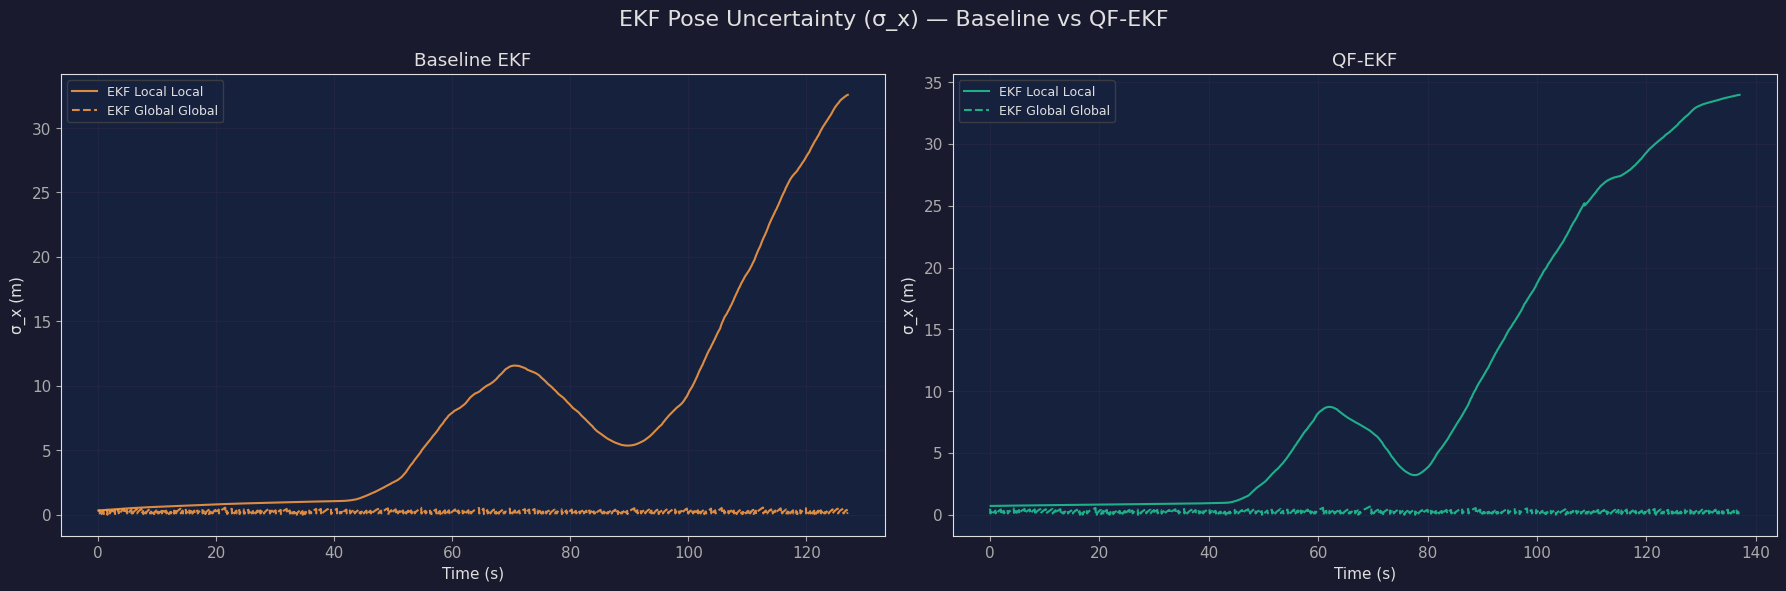

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('EKF Pose Uncertainty (σ_x) — Baseline vs QF-EKF', fontsize=16)

for k, label in [('ekf_local', 'EKF Local'), ('ekf_global', 'EKF Global')]:
    for ax, (dfs, name, c) in zip(axes, [
        (B, 'Baseline', C['b_ekf_l']),
        (Q, 'QF-EKF',   C['q_ekf_l']),
    ]):
        if k not in dfs: continue
        t = npc(dfs[k],'t'); sx = np.sqrt(np.abs(npc(dfs[k],'cov_xx')))
        m = mask_finite(t, sx)
        ls = '-' if k == 'ekf_local' else '--'
        ax.plot(t[m], sx[m], color=c, lw=1.5, ls=ls,
                label=f'{label} {k.replace("ekf_","").title()}', alpha=0.85)

for ax, name in zip(axes, ['Baseline EKF', 'QF-EKF']):
    ax.set_title(name); ax.set_xlabel('Time (s)'); ax.set_ylabel('σ_x (m)')
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/07_covariance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Final Quantitative Comparison Table

In [10]:
print('=' * 75)
print('QUANTITATIVE COMPARISON: BASELINE EKF vs QF-EKF')
print('=' * 75)

# ── Drift ──
print('\n[DRIFT]')
print(f'{"":>18}  {"Final (m)":>10}  {"Max (m)":>9}  {"Rate (m/min)":>14}')
print('─' * 58)
for label, t_c, drift in [('Baseline EKF', t_b, drift_b), ('QF-EKF', t_q, drift_q)]:
    if t_c is None: continue
    dur = t_c[-1] - t_c[0]
    print(f'{label:>18}  {drift[-1]:10.4f}  {drift.max():9.4f}  {drift[-1]/dur*60:14.4f}')

# ── IMU Noise ──
print('\n[IMU NOISE REDUCTION (QNN filter)]')
print(f'{"Channel":>10}  {"Baseline σ":>11}  {"QF-EKF σ":>10}  {"Reduction%":>12}')
print('─' * 50)
for col, label in [('gz','Gyro Z'),('ax','Accel X'),('ay','Accel Y')]:
    sr = noise_std(npc(B['imu'],col)[np.isfinite(npc(B['imu'],col))]) if 'imu' in B else None
    sf = noise_std(npc(Q['imu_flt'],col)[np.isfinite(npc(Q['imu_flt'],col))]) if 'imu_flt' in Q else None
    if sr and sf:
        red = (1 - sf/sr) * 100
        print(f'{label:>10}  {sr:11.5f}  {sf:10.5f}  {red:11.1f}%')

# ── GPS Innovation ──
print('\n[GPS INNOVATION RMSE]')
if ix_b is not None: print(f'  Baseline EKF: {np.sqrt(np.mean(ix_b**2+iy_b**2)):.4f} m')
if ix_q is not None: print(f'  QF-EKF      : {np.sqrt(np.mean(ix_q**2+iy_q**2)):.4f} m')

# ── Closure Error ──
print('\n[CLOSURE ERROR (EKF Local)]')
for label, dfs in [('Baseline EKF', B), ('QF-EKF', Q)]:
    if 'ekf_local' not in dfs: continue
    x = npc(dfs['ekf_local'],'x'); y = npc(dfs['ekf_local'],'y')
    m = mask_finite(x,y)
    if m.sum() > 1:
        err = np.sqrt((x[m][-1]-x[m][0])**2 + (y[m][-1]-y[m][0])**2)
        print(f'  {label}: {err:.4f} m')

print('\n' + '=' * 75)

QUANTITATIVE COMPARISON: BASELINE EKF vs QF-EKF

[DRIFT]
                     Final (m)    Max (m)    Rate (m/min)
──────────────────────────────────────────────────────────
      Baseline EKF     18.0701    18.4139          8.5380
            QF-EKF     21.1303    30.8620          9.2633

[IMU NOISE REDUCTION (QNN filter)]
   Channel   Baseline σ    QF-EKF σ    Reduction%
──────────────────────────────────────────────────
    Gyro Z      0.01076     0.00965         10.3%
   Accel X      0.25076     0.07049         71.9%
   Accel Y      0.22970     0.08303         63.9%

[GPS INNOVATION RMSE]
  Baseline EKF: 14.5121 m
  QF-EKF      : 14.2844 m

[CLOSURE ERROR (EKF Local)]
  Baseline EKF: 15.7815 m
  QF-EKF: 19.8142 m

